In [64]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling and Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, f1_score, confusion_matrix, classification_report

import joblib

In [65]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("mosapabdelghany/medical-insurance-cost-dataset")

In [66]:
import os

# 1. Locate the CSV file in the downloaded path
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

# 2. Load into DataFrame
df = pd.read_csv(full_path)

# 3. Initial Inspection
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [68]:

# Check for missing values and data types
print(df.info())

# Statistical summary of numerical columns
print(df.describe())

# Check for null values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max

/tmp/ipykernel_3166/730453728.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')


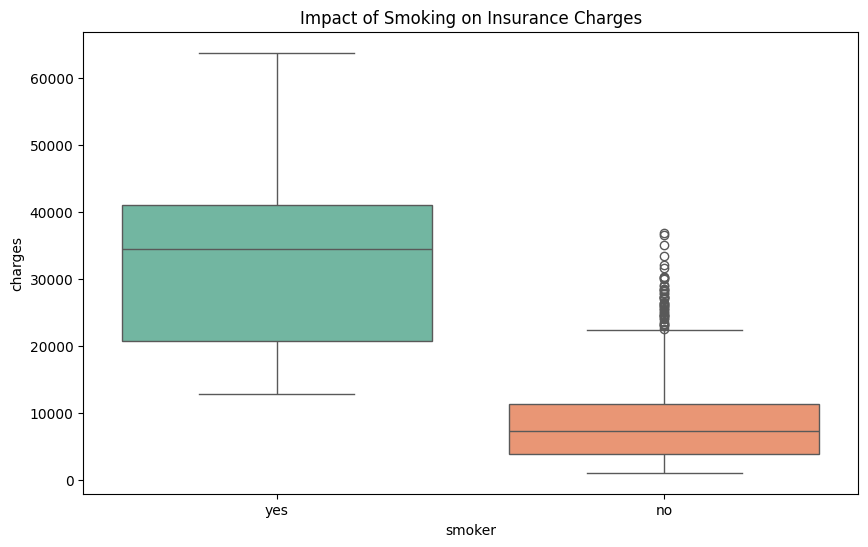

In [69]:


plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title('Impact of Smoking on Insurance Charges')
plt.show()



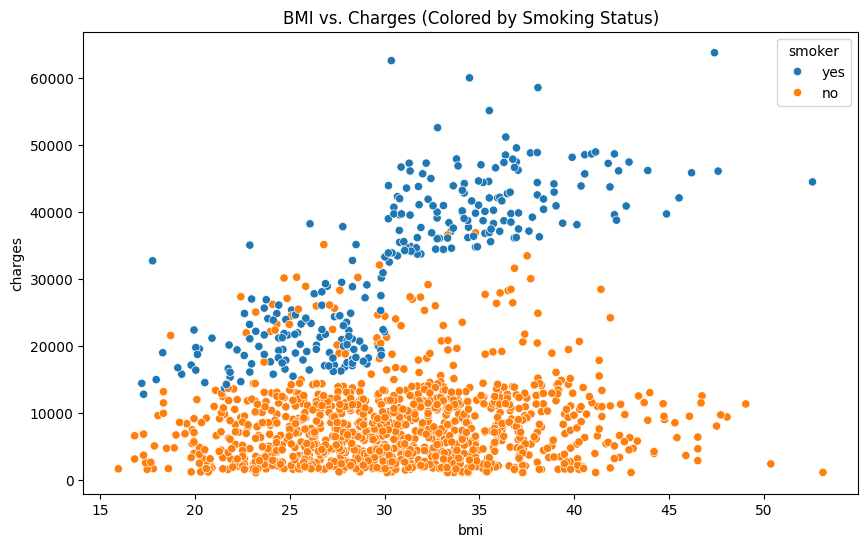

In [70]:


plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('BMI vs. Charges (Colored by Smoking Status)')
plt.show()



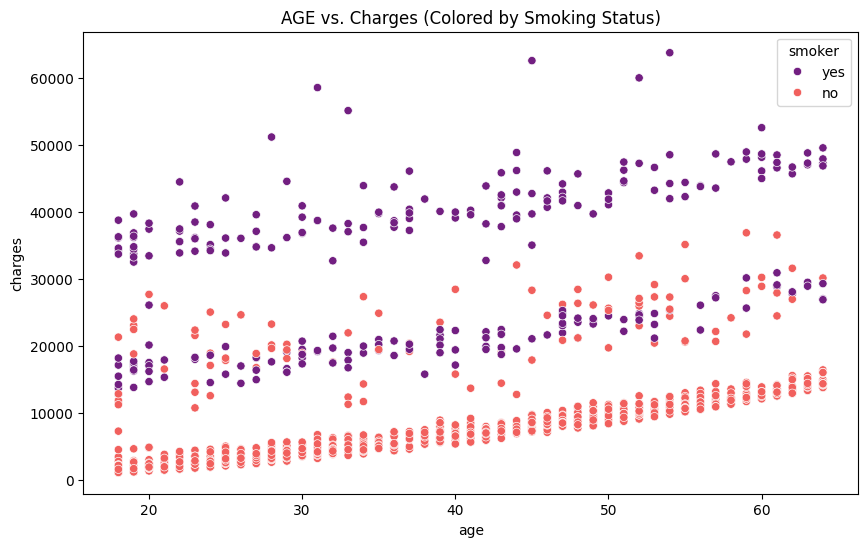

In [71]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, palette='magma')
plt.title('AGE vs. Charges (Colored by Smoking Status)')
plt.show()


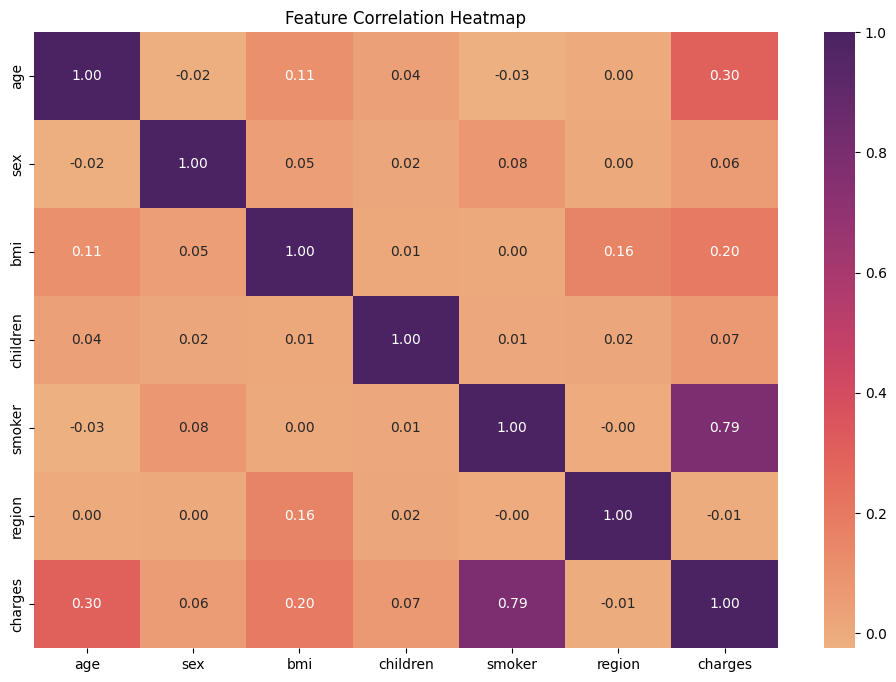

In [72]:
# temporarily encode just for the heatmap
temp_df = df.copy()
for col in ['sex', 'smoker', 'region']:
    temp_df[col] = LabelEncoder().fit_transform(temp_df[col])

plt.figure(figsize=(12, 8))
sns.heatmap(temp_df.corr(), annot=True, cmap='flare', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [73]:
# --- PHASE 3: PREPROCESSING ---

# 1. Encoding Categorical Variables
# Binary encoding for gender (0/1)
df['sex'] = df['sex'].map({'male': 1, 'female': 0})

In [74]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,yes,southwest,16884.92400
1,18,1,33.770,1,no,southeast,1725.55230
2,28,1,33.000,3,no,southeast,4449.46200
3,33,1,22.705,0,no,northwest,21984.47061
4,32,1,28.880,0,no,northwest,3866.85520


In [75]:
# Binary encoding for smoker (0/1)
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

In [76]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [77]:
# 2. One-Hot Encoding ALL Regions (Presentable version)

region_dummies = pd.get_dummies(df['region'], prefix='region', drop_first=False)
df = pd.concat([df, region_dummies], axis=1)

In [78]:
df.head()

,age,sex,bmi,children,smoker,region,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,southwest,16884.92400,False,False,False,True
1,18,1,33.770,1,0,southeast,1725.55230,False,False,True,False
2,28,1,33.000,3,0,southeast,4449.46200,False,False,True,False
3,33,1,22.705,0,0,northwest,21984.47061,False,True,False,False
4,32,1,28.880,0,0,northwest,3866.85520,False,True,False,False


In [80]:
# High BMI + Smoking = Exponentially higher health risk/cost.

df['bmi_smoker_int'] = df['bmi'] * df['smoker']

# 3. Define the Clean Feature Set (X) and Target (y)
# drop the original string columns and 'charges'
features = ['age', 'bmi', 'children', 'sex', 'smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_smoker_int']

X = df[features]
y = df['charges']

print(features)

['age', 'bmi', 'children', 'sex', 'smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_smoker_int']


In [81]:
# 4. Train-Test Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [82]:
# 5. Feature Scaling

scaler = StandardScaler()
num_cols = ['age', 'bmi', 'children', 'bmi_smoker_int']

# Fit on training data only to avoid data leakage
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [83]:
# 5. Define Classification Bins (For Phase 5 Metrics)
# data distribution (50th percentile = 9.3k, 75th = 16.6k)

def categorize_charges(val):
    if val < 10000: return 0   # Low Cost
    elif val < 30000: return 1  # Medium Cost
    else: return 2             # High Cost (Risk)

# The "Ground Truth" classes for  final evaluation
y_test_actual_classes = y_test.apply(categorize_charges)



In [84]:
# 6. Classification Bins (F1-Score/Accuracy)
def get_performance_bins(val):
    if val < 10000: return 0   # Low
    elif val < 30000: return 1  # Mid
    else: return 2             # High

y_test_classes = y_test.apply(get_performance_bins)

In [85]:
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Features included: {list(X_train.columns)}")
X_train.head()


Training set size: 1070 samples
Testing set size: 268 samples
Features included: ['age', 'bmi', 'children', 'sex', 'smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_smoker_int']


,age,bmi,children,sex,smoker,region_northeast,region_northwest,region_southeast,region_southwest,bmi_smoker_int
560,0.472227,-1.756525,0.734336,0,0,False,True,False,False,-0.495987
1285,0.543313,-1.033082,-0.911192,0,0,True,False,False,False,-0.495987
1142,0.898745,-0.943687,-0.911192,0,0,False,False,True,False,-0.495987
969,-0.025379,0.622393,3.202629,0,0,False,False,True,False,-0.495987
486,1.040918,-1.504893,1.557100,0,0,False,True,False,False,-0.495987


Model Creation

*   Training
*   Tuning
*   Comparison




In [86]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [87]:
# --- 1. BASELINE MODEL: Linear Regression ---

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)


In [88]:
# --- 2. Gradient Boosting with Tuning ---

param_grid = { 'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 4] }

grid_search = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)
best_gb_model = grid_search.best_estimator_

print(best_gb_model)

GradientBoostingRegressor(learning_rate=0.05, random_state=42)


In [89]:
# --- 3. CROSS-VALIDATION (Requirement) ---
cv_scores = cross_val_score(best_gb_model, X_train, y_train, cv=5)

print(cv_scores)

[0.83747246 0.91591659 0.83203992 0.79789069 0.84850732]


In [92]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# --- 1. PREDICTIONS
lr_preds = lr_model.predict(X_test)
gb_preds = best_gb_model.predict(X_test)

# Calculate standard metrics for titles
r2_lr = r2_score(y_test, lr_preds)
r2_gb = r2_score(y_test, gb_preds)
mae_lr = mean_absolute_error(y_test, lr_preds)
mae_gb = mean_absolute_error(y_test, gb_preds)

# Calculate Errors
res_lr = y_test - lr_preds
res_gb = y_test - gb_preds


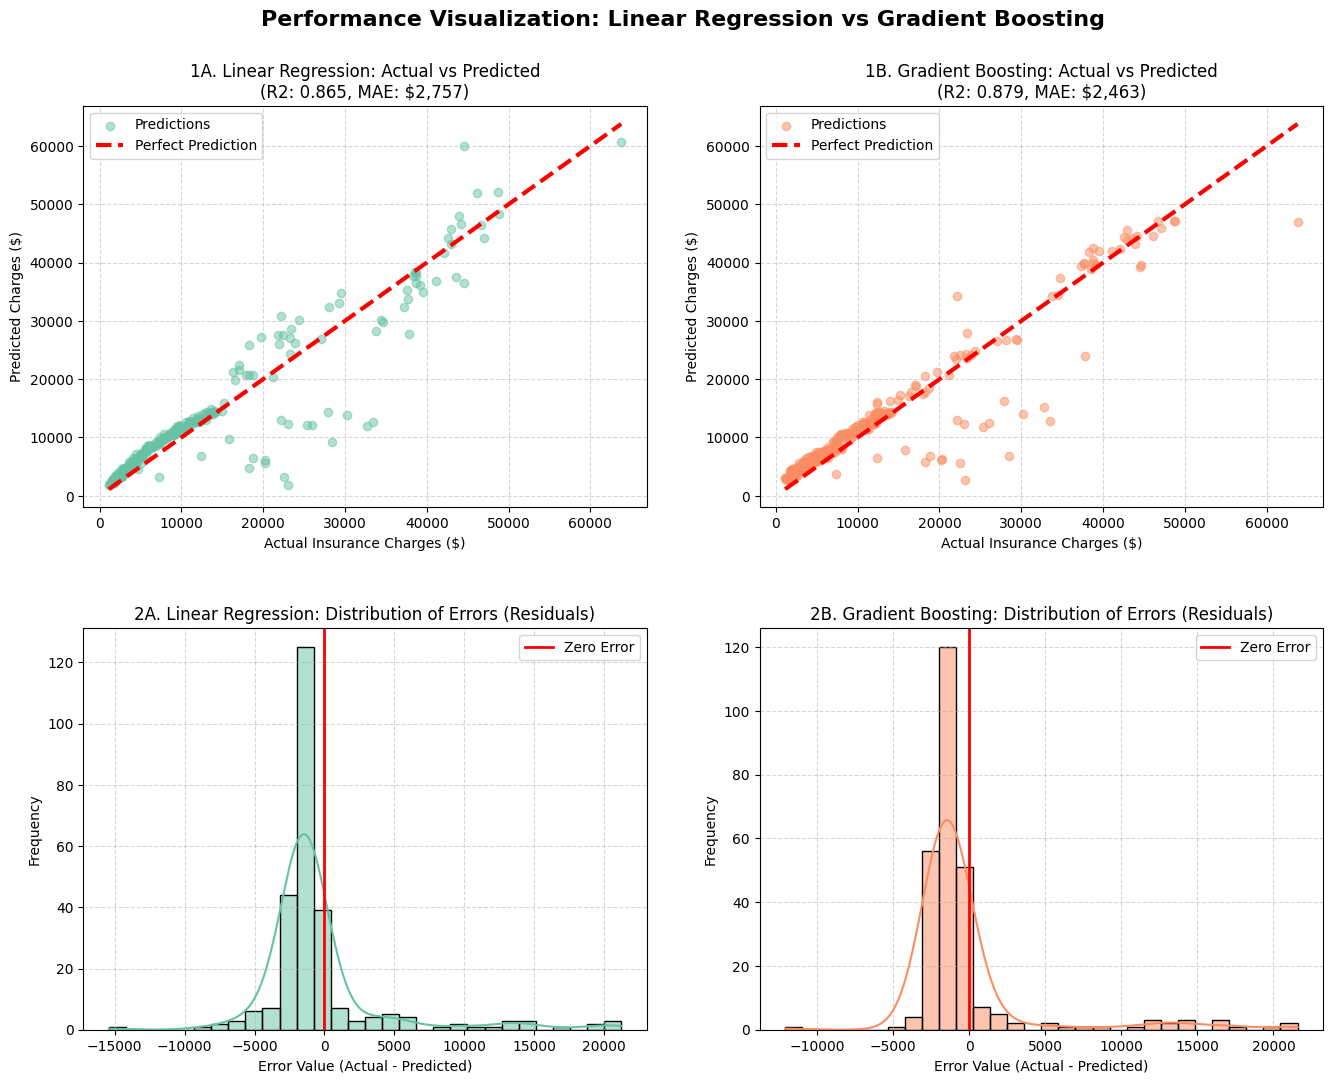

--- Visualisation Analysis ---
Linear Regression R2: 0.8653, MAE: $2756.90
Gradient Boosting R2: 0.8791, MAE: $2462.87
Result: Gradient Boosting is superior. The plots show blue dots clustering much tighter to the red dashed line.


In [91]:
# Create a figure with a 2x2 grid for comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# --- Row 1: Actual vs. Predicted (Scatter) ---

# Graph A: Linear Regression (Baseline)
# Use y_test for both axes to define the 45-degree line limits
line_lims = [y_test.min(), y_test.max()]
axes[0, 0].scatter(y_test, lr_preds, color='#66c2a5', alpha=0.5, label='Predictions')
axes[0, 0].plot(line_lims, line_lims, 'r--', lw=3, label='Perfect Prediction')
axes[0, 0].set_title(f'1A. Linear Regression: Actual vs Predicted\n(R2: {r2_lr:.3f}, MAE: ${mae_lr:,.0f})', fontsize=12)
axes[0, 0].set_xlabel('Actual Insurance Charges ($)')
axes[0, 0].set_ylabel('Predicted Charges ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# Graph B: Gradient Boosting
axes[0, 1].scatter(y_test, gb_preds, color='#fc8d62', alpha=0.5, label='Predictions')
axes[0, 1].plot(line_lims, line_lims, 'r--', lw=3, label='Perfect Prediction')
axes[0, 1].set_title(f'1B. Gradient Boosting: Actual vs Predicted\n(R2: {r2_gb:.3f}, MAE: ${mae_gb:,.0f})', fontsize=12)
axes[0, 1].set_xlabel('Actual Insurance Charges ($)')
axes[0, 1].set_ylabel('Predicted Charges ($)')
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# --- Row 2: Residual Distribution (Histograms/KDE) ---

# Graph C: Linear Regression Residuals
sns.histplot(res_lr, kde=True, color='#66c2a5', ax=axes[1, 0], bins=30)
axes[1, 0].axvline(0, color='red', linestyle='-', lw=2, label='Zero Error')
axes[1, 0].set_title('2A. Linear Regression: Distribution of Errors (Residuals)', fontsize=12)
axes[1, 0].set_xlabel('Error Value (Actual - Predicted)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# Graph D: Gradient Boosting Residuals
sns.histplot(res_gb, kde=True, color='#fc8d62', ax=axes[1, 1], bins=30)
axes[1, 1].axvline(0, color='red', linestyle='-', lw=2, label='Zero Error')
axes[1, 1].set_title('2B. Gradient Boosting: Distribution of Errors (Residuals)', fontsize=12)
axes[1, 1].set_xlabel('Error Value (Actual - Predicted)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

# Set common supertitle
plt.suptitle('Performance Visualization: Linear Regression vs Gradient Boosting', fontsize=16, y=0.96, fontweight='bold')
plt.show()

# --- Quick Summary ---
print(f"--- Visualisation Analysis ---")
print(f"Linear Regression R2: {r2_lr:.4f}, MAE: ${mae_lr:.2f}")
print(f"Gradient Boosting R2: {r2_gb:.4f}, MAE: ${mae_gb:.2f}")
print(f"Result: Gradient Boosting is superior. The plots show blue dots clustering much tighter to the red dashed line.")

Linear Regression Could not correctly capture the relation between BMI and Smoker. Therefore, predictions are spread out as cost increases because as the data suggested, smokers with a higher bmi have higher insurance premiums.

in contrast, Gradient Boosting does better as it captures the relation between BMI and Smoker. This results in a better accuracy and error values.

Gradient Boosting makes fewer large scale errors than Linear regression

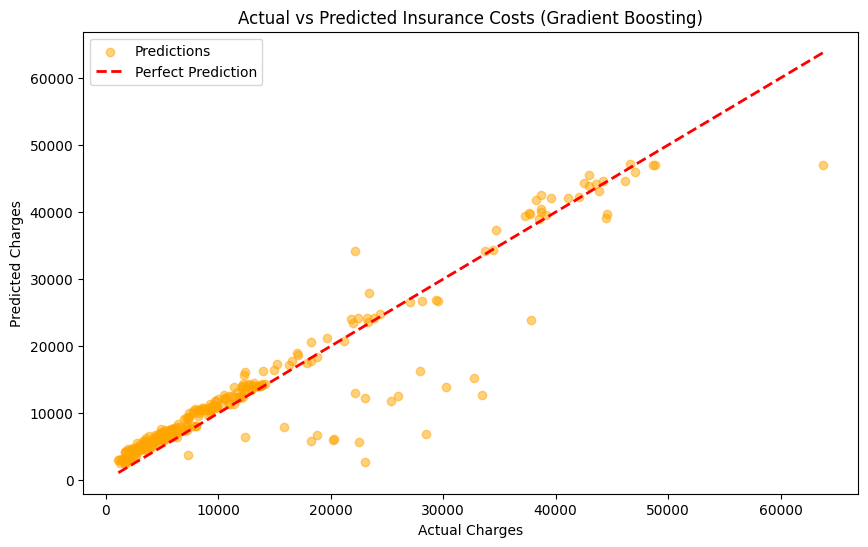

In [93]:
# --- 5. PERFORMANCE GRAPHS: Actual vs Predicted ---
gb_preds = best_gb_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, gb_preds, color='orange', alpha=0.5, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Costs (Gradient Boosting)')
plt.legend()
plt.show()

In [94]:
# --- 6. SUMMARY TABLE ---
print(f"Linear Regression R2: {r2_score(y_test, lr_preds):.4f}")
print(f"Gradient Boosting R2: {r2_score(y_test, gb_preds):.4f}")
print(f"Mean CV Score (5-fold): {cv_scores.mean():.4f}")

Linear Regression R2: 0.8653
Gradient Boosting R2: 0.8791
Mean CV Score (5-fold): 0.8464


Evaluation & Metrics

*   Accuracy
*   Precision
*   F1-score
*   Recall
*   Confusion matrix

In [97]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Convert Continuous Predictions to Bins

def categorize_output(val):
    if val < 10000: return 0   # Low Cost
    elif val < 30000: return 1  # Medium Cost
    else: return 2             # High Cost

In [98]:
# Applying Gradient Boosting predictions

y_pred_classes = [categorize_output(x) for x in gb_preds]

# 2. Calculate Classification Metrics
accuracy = accuracy_score(y_test_classes, y_pred_classes)
class_report = classification_report(y_test_classes, y_pred_classes, target_names=['Low Cost', 'Medium Cost', 'High Cost'])


In [99]:
print(f"Overall Accuracy: {accuracy:.4f}")
print("\nDetailed Classification Report:")
print(class_report)

Overall Accuracy: 0.8507

Detailed Classification Report:
              precision    recall  f1-score   support

    Low Cost       0.93      0.83      0.88       155
 Medium Cost       0.70      0.88      0.78        80
   High Cost       0.97      0.88      0.92        33

    accuracy                           0.85       268
   macro avg       0.87      0.86      0.86       268
weighted avg       0.87      0.85      0.85       268



The Model suffer in the medium cost range as evident by the graphs and the initial distribution of data. The medium range is characterized by a mix of smokers and non smokers spread out over a large range. The Model fails to accurately capture the relation in this range without the risk of overfitting.

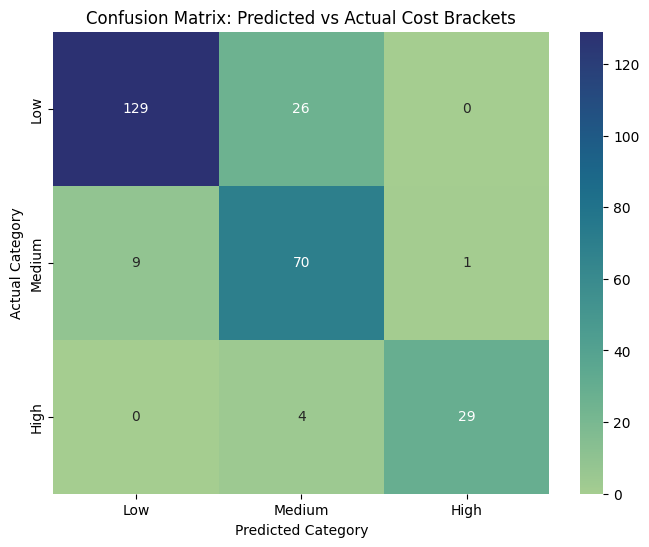

In [100]:
# 3. Visualizing the Confusion Matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix: Predicted vs Actual Cost Brackets')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()